In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error

In [2]:
# Load Data
data_path = "/Users/alexzheng/Developer/GitHub/EC331-project/EMH/Data/Bitcoin_data_full.csv"
df = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Use only the "Returns%" column for GARCH modeling
returns = df["Returns%"].astype(np.float32)

# Normalize Data for Stability
returns = (returns - returns.mean()) / returns.std()

In [3]:
# Split into Train and Test Sets (99.99% Training, 0.01% Testing)
split = int(len(returns) * 0.9999)

train_returns = returns[:split]
test_returns = returns[split:]
test_size = test_returns.shape[0]
print(f"Test Size: {test_size}")

# Normalize using TRAINING data only
train_mean = train_returns.mean()
train_std = train_returns.std()
train_returns = (train_returns - train_mean) / train_std
test_returns = (test_returns - train_mean) / train_std

Test Size: 51


In [4]:
# Fit GARCH(1,1) Model with Stable Optimizer
model = arch_model(train_returns, vol="Garch", p=1, q=1, dist="skewt")
garch_fit = model.fit(disp="off", options={"maxiter": 500, "ftol": 1e-6})
print(garch_fit.summary())

                           Constant Mean - GARCH Model Results                           
Dep. Variable:                          Returns%   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -554368.
Distribution:      Standardized Skew Student's t   AIC:                       1.10875e+06
Method:                       Maximum Likelihood   BIC:                       1.10881e+06
                                                   No. Observations:               509280
Date:                           Tue, Feb 18 2025   Df Residuals:                   509279
Time:                                   13:11:13   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------

In [5]:
if garch_fit.convergence_flag:
    print("WARNING: Model did NOT converge properly!")
else:
    print("Model converged successfully!")

Model converged successfully!


In [6]:
# Retraining loop (now using properly normalized data)
rolling_predictions = []
for i in range(test_size):
    train = pd.concat([train_returns, test_returns[:i]])  # Make sure no future leakage
    model = arch_model(train, vol="Garch", p=1, q=1, dist="skewt")
    model_fit = model.fit(disp="off")
    forecast = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(forecast.variance.values[-1, 0]))

In [7]:
# Compute Realized Volatility (Remove NaNs from Rolling Window)
realized_volatility = test_returns.rolling(window=30).std()
realized_volatility = realized_volatility.iloc[30:]  # Align with predictions

# Ensure Rolling Predictions Start at the Same Time
rolling_predictions = pd.Series(rolling_predictions, index=test_returns.index[:len(rolling_predictions)])
rolling_predictions = rolling_predictions[30:]  # Align with realized volatility

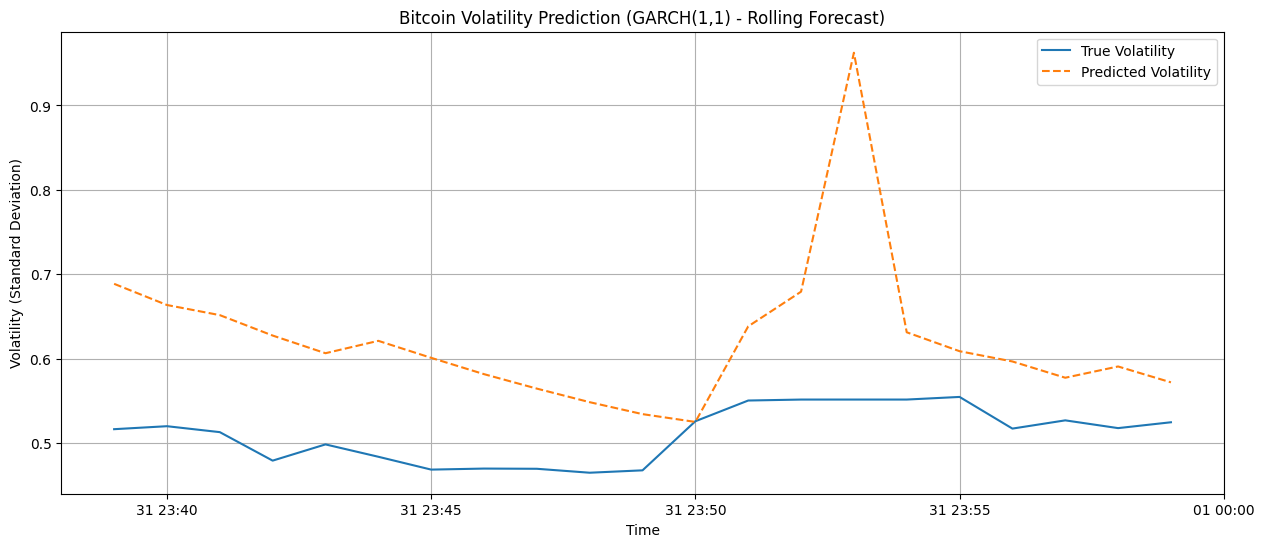

In [8]:
# Plot Forecasted vs. Realized Volatility
plt.figure(figsize=(15, 6))
plt.plot(realized_volatility.index, realized_volatility, label="True Volatility")
plt.plot(realized_volatility.index, rolling_predictions, label="Predicted Volatility", linestyle="dashed")

plt.xlabel("Time")
plt.ylabel("Volatility (Standard Deviation)")
plt.title("Bitcoin Volatility Prediction (GARCH(1,1) - Rolling Forecast)")
plt.legend()
plt.grid(True)
plt.show()

### Check for robustness

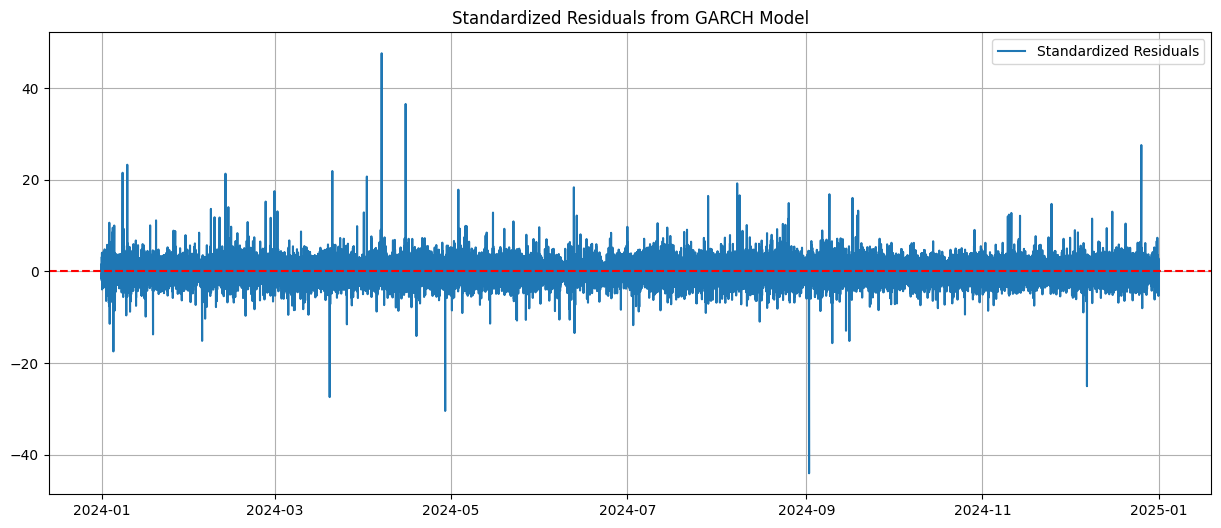

In [9]:
# Plot Standardized Residuals (GARCH Model Output)

# Extract standardized residuals
std_residuals = garch_fit.resid / garch_fit.conditional_volatility

# Plot standardized residuals
plt.figure(figsize=(15, 6))
plt.plot(std_residuals, label="Standardized Residuals")
plt.axhline(y=0, linestyle="--", color="red")  # Mean line
plt.title("Standardized Residuals from GARCH Model")
plt.legend()
plt.grid(True)
plt.show()

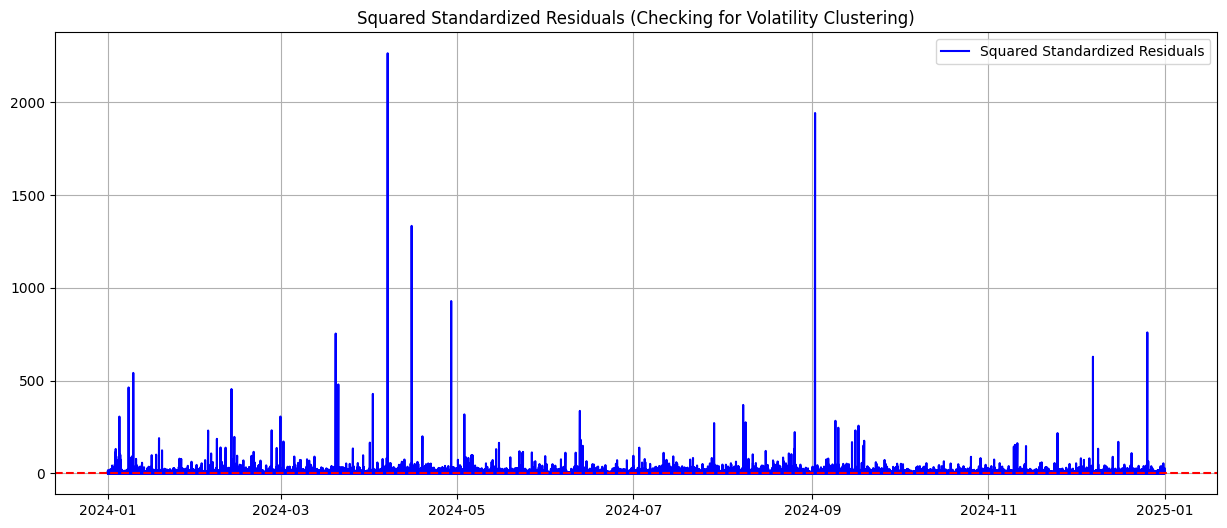

In [10]:
# Plot squared residuals (should not have patterns)
plt.figure(figsize=(15, 6))
plt.plot(std_residuals**2, label="Squared Standardized Residuals", color="blue")
plt.axhline(y=0, linestyle="--", color="red")  # Mean line
plt.title("Squared Standardized Residuals (Checking for Volatility Clustering)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Findings:
# GARCH(1,1) residuals show strong volatility clustering (large spikes followed by persistence)
# -> past volatility can help predict future volatility, meaning the market is not fully efficient.

# Standardized residuals have huge spikes, meaning large shocks occur more frequently than expected.
# This suggests non-randomness in price movements.

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = garch_fit.resid ** 2  # Squared residuals capture volatility
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

         lb_stat  lb_pvalue
10  54565.992714        0.0


In [ ]:
# Findings:
# Significant autocorrelation in squared residuals